# Actividad 2


In [1]:
from faker import Faker
import random
from datetime import datetime

fake = Faker('es_MX')

def generar_datos_ejemplo(n=100):
    datos = []
    for _ in range(n):
        registro = {
            "nombre": fake.name(),
            "edad": random.randint(18, 99),
            "ciudad": fake.city(),
            "fecha_reporte": fake.date_between(start_date='-2y', end_date='today').strftime('%Y-%m-%d'),
            "categoria": random.choice(['Seguridad', 'Salud', 'Ingeniería', 'Servicios']),
            "genero": random.choice(['Masculino', 'Femenino', 'Otro']),
            "descripcion": fake.sentence(nb_words=10),
            "comentario": fake.paragraph(nb_sentences=3),
            "peso": random.randint(50, 100),
            "latitud": float(fake.latitude()),
            "longitud": float(fake.longitude())
        }
        datos.append(registro)
    return datos


mis_datos = generar_datos_ejemplo(5000)



print(f"Se generaron {len(mis_datos)} registros de ejemplo:")

Se generaron 5000 registros de ejemplo:


# Insertar datos mongodb

In [2]:
from pymongo import MongoClient

def insertar_datos_mongodb(datos):
    try:
        cliente = MongoClient('mongodb://localhost:27017/')
        db = cliente['Actividad2']
        coleccion = db['reportes']

        resultado = coleccion.insert_many(datos)
        print(f"Registros insertados")
    except Exception as e:
        print(f"Error: {e}")
    finally:
        cliente.close()
        print("Conexión cerrada")
insertar_datos_mongodb(mis_datos)

Registros insertados
Conexión cerrada


# Leer con Pandas

In [3]:
from pymongo import MongoClient
import pandas as pd

def Leer_datos_mongodb():
    try:
        cliente = MongoClient('mongodb://localhost:27017/')
        db = cliente['Actividad2']
        coleccion = db['reportes']

        datos = list(coleccion.find())

        df = pd.DataFrame(datos)

        print(df.head())
        print("Datos leídos correctamente")

        return df

    except Exception as e:
        print(f"Error: {e}")
    finally:
        cliente.close()
        print("Conexión cerrada")
dataframe_mongodb = Leer_datos_mongodb()
display(dataframe_mongodb)

                        _id                           nombre  edad  \
0  69c5d4390db0a8579b81eca5                Berta Norma Olmos    83   
1  69c5d4390db0a8579b81eca6  Salvador Darío Cisneros Segovia    47   
2  69c5d4390db0a8579b81eca7            Asunción Solís Ruelas    66   
3  69c5d4390db0a8579b81eca8                   Ofelia Galindo    98   
4  69c5d4390db0a8579b81eca9            Lic. Ariadna Cardenas    25   

                      ciudad fecha_reporte   categoria     genero  \
0                Nueva Benin    2024-10-09   Servicios  Masculino   
1                 Vieja Chad    2024-10-14       Salud   Femenino   
2        Vieja Sudán del Sur    2025-11-26       Salud  Masculino   
3  San Timoteo de la Montaña    2024-06-08  Ingeniería  Masculino   
4              Vieja Argelia    2025-12-21   Seguridad   Femenino   

                                         descripcion  \
0  Banco g obra unión resulta palabra operación p...   
1  Existen él mi hizo primer estar bien ante lejo...

,_id,nombre,edad,ciudad,fecha_reporte,categoria,genero,descripcion,comentario,peso,latitud,longitud
0,69c5d4390db0a8579b81eca5,Berta Norma Olmos,83,Nueva Benin,2024-10-09,Servicios,Masculino,Banco g obra unión resulta palabra operación p...,Según prensa sala mí. Salud menos oficial real...,58,76.435040,-124.949904
1,69c5d4390db0a8579b81eca6,Salvador Darío Cisneros Segovia,47,Vieja Chad,2024-10-14,Salud,Femenino,Existen él mi hizo primer estar bien ante lejo...,Decía partir cuya. Dios opinión principales do...,61,-55.098686,-103.476554
2,69c5d4390db0a8579b81eca7,Asunción Solís Ruelas,66,Vieja Sudán del Sur,2025-11-26,Salud,Masculino,Movimiento concepto g mediante falta pueda sie...,República solamente tan imagen único anterior ...,50,-55.058931,99.353298
3,69c5d4390db0a8579b81eca8,Ofelia Galindo,98,San Timoteo de la Montaña,2024-06-08,Ingeniería,Masculino,Diez etc decía toma jóvenes revolución lo univ...,Fecha nada siendo aquella realizar. Civil apar...,100,-10.254496,14.324623
4,69c5d4390db0a8579b81eca9,Lic. Ariadna Cardenas,25,Vieja Argelia,2025-12-21,Seguridad,Femenino,Ii sería podemos conseguir cualquier todavía f...,Sólo alto juicio. Acciones deja calidad cualqu...,55,-55.591702,-32.440591
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,69c5d4390db0a8579b820028,Armando Bernabé Barragán Guevara,42,San Joaquín de la Montaña,2024-11-29,Ingeniería,Otro,Tales materia lejos hacía mano tema política p...,Tanto siguiente viejo noviembre sabía distinto...,77,-53.097338,-65.234158
4996,69c5d4390db0a8579b820029,Lorenzo de la Rosa Barragán,18,San Enrique los altos,2025-06-26,Seguridad,Otro,De segundo quedó empresas era líder sangre obr...,Metros don aire compañía sí obra cosa. Materia...,71,30.093045,-71.762318
4997,69c5d4390db0a8579b82002a,Conchita Carmen Cuellar,60,San Nelly los altos,2025-08-31,Ingeniería,Femenino,Imposible hija persona fiscal nueva trata arge...,Entrar varias paciente armas acuerdo costa del.,66,48.906055,49.782724
4998,69c5d4390db0a8579b82002b,Hugo Durán,38,San Modesto los altos,2024-05-27,Servicios,Masculino,Investigación negro la supuesto evitar b.,Pasado conseguir autor puedo muerte millones. ...,84,43.980436,5.864196


# Analisis Numerico

In [4]:
import numpy as np

columnas_numericas = ['edad', 'peso', 'latitud', 'longitud']

media = dataframe_mongodb[columnas_numericas].mean()

mediana = dataframe_mongodb[columnas_numericas].median()

moda = dataframe_mongodb[columnas_numericas].mode().iloc[0]

resumen_numerico = pd.DataFrame({
    'Media': media,
    'Mediana': mediana,
    'Moda': moda
})

categoricas = ['ciudad', 'categoria', 'genero']

moda_categoricas = dataframe_mongodb[categoricas].mode().iloc[0]

print("Moda de variables categóricas:")
print(moda_categoricas)

for col in categoricas:
    print(f"\nFrecuencia de {col}:")
    print(dataframe_mongodb[col].value_counts())

print(resumen_numerico)

print("\nResumen general:")
print(dataframe_mongodb.describe(include='all'))

Moda de variables categóricas:
ciudad       Vieja Alemania
categoria        Ingeniería
genero            Masculino
Name: 0, dtype: str

Frecuencia de ciudad:
ciudad
Vieja Alemania                      17
Nueva Papua Nueva Guinea            14
Vieja Noruega                       13
Nueva Malta                         13
Vieja Vietman                       12
                                    ..
San María Eugenia los altos          1
San Marcela los altos                1
San José Eduardo los altos           1
San Vanesa los bajos                 1
San María Cristina de la Montaña     1
Name: count, Length: 1331, dtype: int64

Frecuencia de categoria:
categoria
Ingeniería    1281
Salud         1247
Seguridad     1242
Servicios     1230
Name: count, dtype: int64

Frecuencia de genero:
genero
Masculino    1703
Otro         1676
Femenino     1621
Name: count, dtype: int64
              Media    Mediana        Moda
edad      58.247000  58.000000   55.000000
peso      75.074800  75.000000  

# Graficas

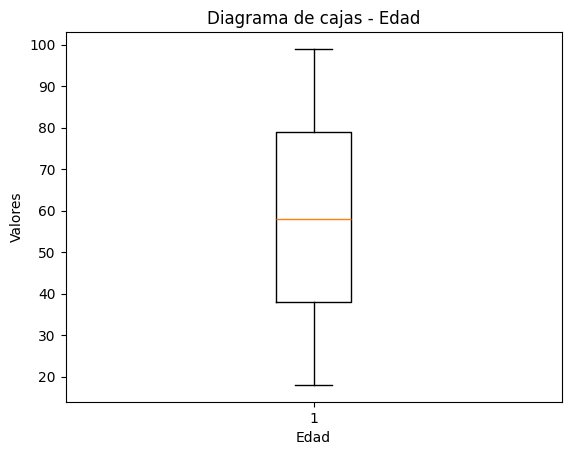

In [5]:
# Cajas

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(dataframe_mongodb['edad'])
plt.title("Diagrama de cajas - Edad")
plt.xlabel("Edad")
plt.ylabel("Valores")

plt.show()

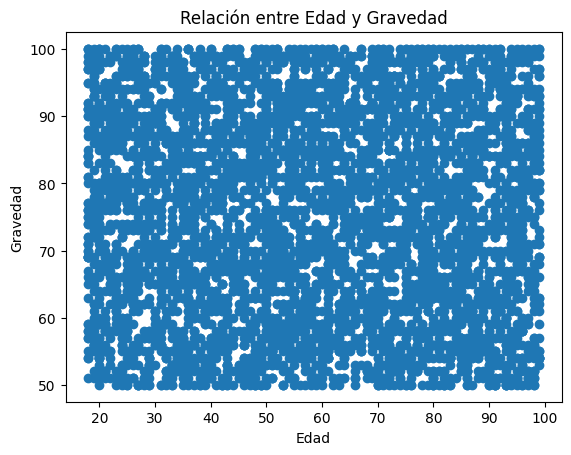

In [7]:
# Dispersión

plt.figure()
plt.scatter(dataframe_mongodb['edad'], dataframe_mongodb['peso'])

plt.title("Relación entre Edad y Gravedad")
plt.xlabel("Edad")
plt.ylabel("Gravedad")

plt.show()

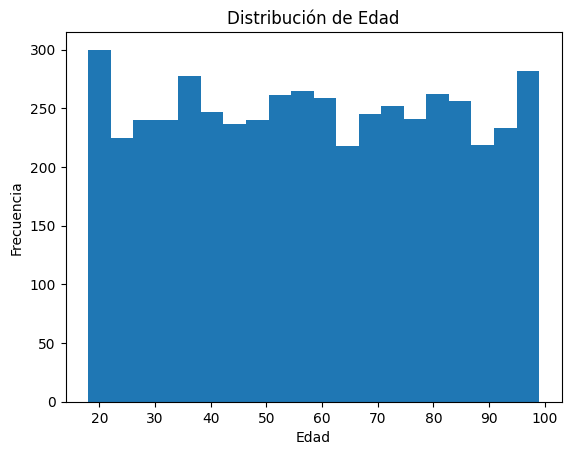

In [8]:
# Histograma

plt.figure()
plt.hist(dataframe_mongodb['edad'], bins=20)

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()